# E-Commerce Customer Analytics
## Phase 2 — Data Cleaning
**Dataset:** Olist Brazilian E-Commerce  
**Goal:** Fix data quality issues identified during EDA and produce a single clean,
analysis-ready table saved to `data/processed/`.

### What we learned from EDA that guides this phase:
- Several columns have missing values (especially in orders and reviews)
- Date columns are stored as strings — they need to be converted to datetime
- Most orders are 'delivered' — we'll filter to these for RFM analysis
- Revenue has extreme outliers that need to be flagged
- `customer_unique_id` is the true customer identifier, not `customer_id`
- The dataset spans multiple tables that need to be merged into one master table

---
## 1. Import Libraries & Configure Paths

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)

# Build absolute paths so the notebook works regardless of where it's opened from
# os.path.expanduser('~') resolves to your home directory (e.g. /Users/omartouzani)
PROJECT_ROOT = os.path.expanduser('~/Desktop/ecommerce-customer-analytics')
RAW_PATH     = os.path.join(PROJECT_ROOT, 'data', 'raw') + '/'
PROCESSED_PATH = os.path.join(PROJECT_ROOT, 'data', 'processed') + '/'
DOCS_PATH    = os.path.join(PROJECT_ROOT, 'docs')

# Create the processed folder if it doesn't exist yet
# This is where we'll save our cleaned output files
os.makedirs(PROCESSED_PATH, exist_ok=True)
os.makedirs(DOCS_PATH, exist_ok=True)

print('Libraries loaded ✅')
print(f'Raw data path:       {RAW_PATH}')
print(f'Processed data path: {PROCESSED_PATH}')

Libraries loaded ✅
Raw data path:       /Users/omartouzani/Desktop/ecommerce-customer-analytics/data/raw/
Processed data path: /Users/omartouzani/Desktop/ecommerce-customer-analytics/data/processed/


---
## 2. Load the Raw Datasets
We reload all tables fresh from the raw folder.
Never modify raw files — always work on copies. This protects the original data
and lets us re-run the cleaning pipeline from scratch at any time.

In [18]:
# Load all raw datasets — same as in EDA
orders      = pd.read_csv(RAW_PATH + 'olist_orders_dataset.csv')
order_items = pd.read_csv(RAW_PATH + 'olist_order_items_dataset.csv')
payments    = pd.read_csv(RAW_PATH + 'olist_order_payments_dataset.csv')
reviews     = pd.read_csv(RAW_PATH + 'olist_order_reviews_dataset.csv')
customers   = pd.read_csv(RAW_PATH + 'olist_customers_dataset.csv')
sellers     = pd.read_csv(RAW_PATH + 'olist_sellers_dataset.csv')
products    = pd.read_csv(RAW_PATH + 'olist_products_dataset.csv')
category_tr = pd.read_csv(RAW_PATH + 'product_category_name_translation.csv')

print(f'orders:      {orders.shape}')
print(f'order_items: {order_items.shape}')
print(f'payments:    {payments.shape}')
print(f'reviews:     {reviews.shape}')
print(f'customers:   {customers.shape}')
print(f'sellers:     {sellers.shape}')
print(f'products:    {products.shape}')
print('\nAll datasets loaded ✅')

orders:      (99441, 8)
order_items: (112650, 7)
payments:    (103886, 5)
reviews:     (99224, 7)
customers:   (99441, 5)
sellers:     (3095, 4)
products:    (32951, 9)

All datasets loaded ✅


---
## 3. Clean the Orders Table
The orders table is the backbone of the dataset — everything joins to it.
We need to fix date types, filter to relevant orders, and handle missing timestamps.

### 3a. Convert Date Columns to Datetime

In [3]:
# Check the current data types before conversion
# All date columns are currently stored as 'object' (string) — we need them as datetime
print('Data types before conversion:')
print(orders.dtypes)

# List of all date columns in the orders table
date_columns = [
    'order_purchase_timestamp',    # when the customer placed the order
    'order_approved_at',           # when payment was confirmed
    'order_delivered_carrier_date',# when the seller handed to the carrier
    'order_delivered_customer_date',# when the customer received the order
    'order_estimated_delivery_date' # the estimated delivery date shown to customer
]

# Convert each date column from string to datetime
# errors='coerce' turns any unparseable values into NaT (Not a Time) instead of crashing
# This is safer than errors='raise' which would stop execution on a single bad value
for col in date_columns:
    orders[col] = pd.to_datetime(orders[col], errors='coerce')

print('\nData types after conversion:')
print(orders.dtypes)

Data types before conversion:
order_id                         object
customer_id                      object
order_status                     object
order_purchase_timestamp         object
order_approved_at                object
order_delivered_carrier_date     object
order_delivered_customer_date    object
order_estimated_delivery_date    object
dtype: object

Data types after conversion:
order_id                                 object
customer_id                              object
order_status                             object
order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
dtype: object


### 3b. Filter to Delivered Orders Only
For RFM analysis and sales forecasting, we only want orders that were successfully
delivered to the customer. Cancelled, unavailable, or in-progress orders would
skew our revenue and frequency calculations.

In [4]:
# Check the distribution before filtering so we know what we're removing
print('Order status counts before filtering:')
print(orders['order_status'].value_counts())
print(f'\nTotal orders before filter: {len(orders):,}')

# Keep only delivered orders
# This is where business context matters — 'delivered' means the transaction is complete
orders_clean = orders[orders['order_status'] == 'delivered'].copy()

# .copy() is important here — it creates a true independent copy
# Without it, pandas may raise a SettingWithCopyWarning when we modify the DataFrame later

print(f'Total orders after filter:  {len(orders_clean):,}')
print(f'Orders removed:             {len(orders) - len(orders_clean):,}')

Order status counts before filtering:
order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

Total orders before filter: 99,441
Total orders after filter:  96,478
Orders removed:             2,963


### 3c. Handle Missing Values in Orders

In [5]:
# Check missing values in the cleaned orders table
print('Missing values in orders_clean:')
missing = orders_clean.isnull().sum()
print(missing[missing > 0])

# order_approved_at: a small number of orders have no approval timestamp
# These are edge cases (e.g. payment processing delays)
# We drop them since we can't reliably use orders with no confirmed payment
before = len(orders_clean)
orders_clean = orders_clean.dropna(subset=['order_approved_at'])
print(f'\nRows dropped (missing order_approved_at): {before - len(orders_clean):,}')

# order_delivered_customer_date: some delivered orders are missing actual delivery date
# This is a data entry issue on the seller/carrier side
# We drop these too since delivery date is needed for our delivery time analysis
before = len(orders_clean)
orders_clean = orders_clean.dropna(subset=['order_delivered_customer_date'])
print(f'Rows dropped (missing delivery date):     {before - len(orders_clean):,}')

print(f'\nFinal orders_clean shape: {orders_clean.shape}')

Missing values in orders_clean:
order_approved_at                14
order_delivered_carrier_date      2
order_delivered_customer_date     8
dtype: int64

Rows dropped (missing order_approved_at): 14
Rows dropped (missing delivery date):     8

Final orders_clean shape: (96456, 8)


### 3d. Engineer Delivery Time Feature
While we have the dates, we engineer a useful derived feature: how many days
did delivery actually take? This will be valuable for customer satisfaction analysis.

In [6]:
# Calculate actual delivery time in days
# Subtracting two datetime columns gives a Timedelta — .dt.days converts it to an integer
orders_clean['delivery_days'] = (
    orders_clean['order_delivered_customer_date'] -
    orders_clean['order_purchase_timestamp']
).dt.days

# Calculate how many days early or late the delivery was vs the estimate
# Negative = delivered early (good), Positive = delivered late (bad)
orders_clean['delivery_delay_days'] = (
    orders_clean['order_delivered_customer_date'] -
    orders_clean['order_estimated_delivery_date']
).dt.days

# Sanity check: delivery days should be positive
# Any negative values would indicate a data error (delivered before purchase)
invalid_delivery = (orders_clean['delivery_days'] <= 0).sum()
print(f'Orders with invalid delivery time (<=0 days): {invalid_delivery}')

# Remove any rows with invalid delivery times
orders_clean = orders_clean[orders_clean['delivery_days'] > 0]

print(f'\nDelivery Time Summary (days):')
print(orders_clean['delivery_days'].describe().round(1))

Orders with invalid delivery time (<=0 days): 13

Delivery Time Summary (days):
count    96443.0
mean        12.1
std          9.6
min          1.0
25%          6.0
50%         10.0
75%         15.0
max        209.0
Name: delivery_days, dtype: float64


---
## 4. Clean the Payments Table
We need the total revenue per order. Some orders have multiple payment rows
(e.g. partial payments, vouchers combined with credit cards).
We aggregate these into a single revenue figure per order.

In [7]:
# Check for missing values in payments
print('Missing values in payments:')
print(payments.isnull().sum())

# Check for any zero or negative payment values — these would be data errors
print(f'\nZero or negative payment values: {(payments["payment_value"] <= 0).sum()}')

# Aggregate total payment value per order
# A single order can have multiple rows in this table (split payments)
# We also capture the primary payment type (most common method used in the order)
payments_clean = payments.groupby('order_id').agg(
    total_payment=('payment_value', 'sum'),          # total amount paid
    payment_installments=('payment_installments', 'max'),  # max installments used
    payment_type=('payment_type', lambda x: x.mode()[0])   # most common payment method
).reset_index()

# Remove orders where total payment is zero or negative
# These represent voided or erroneous transactions
before = len(payments_clean)
payments_clean = payments_clean[payments_clean['total_payment'] > 0]
print(f'\nPayment rows removed (zero/negative value): {before - len(payments_clean)}')
print(f'payments_clean shape: {payments_clean.shape}')

Missing values in payments:
order_id                0
payment_sequential      0
payment_type            0
payment_installments    0
payment_value           0
dtype: int64

Zero or negative payment values: 9

Payment rows removed (zero/negative value): 3
payments_clean shape: (99437, 4)


---
## 5. Clean the Order Items Table
We aggregate item-level data to order level — total items, total price, total freight.
This makes it easier to join with the orders table later.

In [8]:
# Check for missing values
print('Missing values in order_items:')
print(order_items.isnull().sum())

# Add English category names to products
# LEFT JOIN keeps all products, even those without a translation
products_en = products.merge(category_tr, on='product_category_name', how='left')

# Join order items with product categories
items_enriched = order_items.merge(
    products_en[['product_id', 'product_category_name_english']],
    on='product_id',
    how='left'
)

# Aggregate from item level to order level
# Each order can contain multiple items — we summarize them into single row per order
order_items_clean = items_enriched.groupby('order_id').agg(
    item_count=('order_item_id', 'count'),              # number of items in the order
    total_items_price=('price', 'sum'),                 # total product price before freight
    total_freight=('freight_value', 'sum'),             # total shipping cost
    # For category, take the most frequent category in the order
    # Most orders have one item so this will just be that item's category
    primary_category=('product_category_name_english', lambda x: x.mode()[0] if not x.mode().empty else 'unknown')
).reset_index()

print(f'order_items_clean shape: {order_items_clean.shape}')
print('\nSample:')
print(order_items_clean.head(3))

Missing values in order_items:
order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64
order_items_clean shape: (98666, 5)

Sample:
                           order_id  item_count  total_items_price  \
0  00010242fe8c5a6d1ba2dd792cb16214           1               58.9   
1  00018f77f2f0320c557190d7a144bdd3           1              239.9   
2  000229ec398224ef6ca0657da4fc703e           1              199.0   

   total_freight primary_category  
0          13.29       cool_stuff  
1          19.93         pet_shop  
2          17.87  furniture_decor  


---
## 6. Clean the Reviews Table
Reviews have missing text fields (title and message) which is expected —
customers aren't required to write a comment. We keep the score which is always present.

In [9]:
# Check missing values
print('Missing values in reviews:')
print(reviews.isnull().sum())

# Keep only the columns we'll actually use in the analysis
# review_comment_title and review_comment_message are optional text fields
# We drop them to keep the dataset lean — they'd require NLP to be useful
reviews_clean = reviews[['order_id', 'review_score']].copy()

# Some orders have multiple reviews (re-submissions by customers)
# Keep only the most recent review per order to avoid double-counting
# We use drop_duplicates keeping the last entry after sorting by review_id
reviews_clean = reviews_clean.drop_duplicates(subset='order_id', keep='last')

print(f'\nreviews_clean shape: {reviews_clean.shape}')
print(f'Missing review scores: {reviews_clean["review_score"].isnull().sum()}')

Missing values in reviews:
review_id                      0
order_id                       0
review_score                   0
review_comment_title       87656
review_comment_message     58247
review_creation_date           0
review_answer_timestamp        0
dtype: int64

reviews_clean shape: (98673, 2)
Missing review scores: 0


---
## 7. Clean the Customers Table
The key fix here is using `customer_unique_id` as the true customer identifier.
We also standardize state codes to uppercase.

In [10]:
# Check for missing values
print('Missing values in customers:')
print(customers.isnull().sum())

# Check for duplicate customer_unique_id values
# There should be none — each unique customer should appear only once
dupes = customers['customer_unique_id'].duplicated().sum()
print(f'\nDuplicate customer_unique_id values: {dupes}')

# Keep only the columns we need
# We don't need zip code prefix for our analysis
customers_clean = customers[[
    'customer_id',         # used to join with orders
    'customer_unique_id',  # true unique customer identifier (for RFM)
    'customer_city',
    'customer_state'
]].copy()

# Standardize state codes to uppercase to avoid mismatches (e.g. 'sp' vs 'SP')
customers_clean['customer_state'] = customers_clean['customer_state'].str.upper().str.strip()
customers_clean['customer_city'] = customers_clean['customer_city'].str.title().str.strip()

print(f'\ncustomers_clean shape: {customers_clean.shape}')

Missing values in customers:
customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

Duplicate customer_unique_id values: 3345

customers_clean shape: (99441, 4)


---
## 8. Build the Master Analytical Table
Now we merge all cleaned tables into a single wide DataFrame.
This is the table we'll use for all downstream analysis — RFM, clustering, and forecasting.

The join strategy is:
1. Start with `orders_clean` (our filtered, delivered orders)
2. Add customer info
3. Add payment totals
4. Add order item details
5. Add review scores

We use LEFT JOINs throughout so we never lose orders due to missing data in other tables.

In [11]:
# Step 1: Start with delivered orders as the base
master = orders_clean.copy()
print(f'Base (orders_clean):       {master.shape}')

# Step 2: Add customer details
# Join on customer_id (the order-level key that links orders to customers)
master = master.merge(customers_clean, on='customer_id', how='left')
print(f'After adding customers:    {master.shape}')

# Step 3: Add payment totals
master = master.merge(payments_clean, on='order_id', how='left')
print(f'After adding payments:     {master.shape}')

# Step 4: Add order item details (item count, prices, freight, category)
master = master.merge(order_items_clean, on='order_id', how='left')
print(f'After adding order items:  {master.shape}')

# Step 5: Add review scores
master = master.merge(reviews_clean, on='order_id', how='left')
print(f'After adding reviews:      {master.shape}')

print('\nMaster table columns:')
print(list(master.columns))

Base (orders_clean):       (96443, 10)
After adding customers:    (96443, 13)
After adding payments:     (96443, 16)
After adding order items:  (96443, 20)
After adding reviews:      (96443, 21)

Master table columns:
['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'delivery_days', 'delivery_delay_days', 'customer_unique_id', 'customer_city', 'customer_state', 'total_payment', 'payment_installments', 'payment_type', 'item_count', 'total_items_price', 'total_freight', 'primary_category', 'review_score']


---
## 9. Final Cleaning on Master Table
After merging, we do a final pass to handle any remaining issues introduced by the joins.

In [12]:
# Check missing values in the master table after all merges
print('Missing values in master table:')
missing = master.isnull().sum()
print(missing[missing > 0])

Missing values in master table:
order_delivered_carrier_date      1
total_payment                     1
payment_installments              1
payment_type                      1
review_score                    646
dtype: int64


In [13]:
# Drop rows missing payment data — these orders have no revenue and are unusable for RFM
before = len(master)
master = master.dropna(subset=['total_payment'])
print(f'Rows dropped (missing payment): {before - len(master)}')

# Fill missing review scores with the median score
# We use median rather than mean because review scores are ordinal (1-5 scale)
# and the median is more robust to skewed distributions
median_score = master['review_score'].median()
master['review_score'] = master['review_score'].fillna(median_score)
print(f'Missing review scores filled with median: {median_score}')

# Fill missing item counts and freight with 0 as a safe fallback
master['item_count'] = master['item_count'].fillna(0).astype(int)
master['total_freight'] = master['total_freight'].fillna(0)

# Fill missing primary category with 'unknown'
master['primary_category'] = master['primary_category'].fillna('unknown')

print(f'\nMissing values after final cleaning:')
remaining = master.isnull().sum()
print(remaining[remaining > 0] if remaining[remaining > 0].any() else 'None ✅')

Rows dropped (missing payment): 1
Missing review scores filled with median: 5.0

Missing values after final cleaning:
order_delivered_carrier_date    1
dtype: int64


### 9b. Handle Revenue Outliers
We identified extreme outliers in the revenue distribution during EDA.
Rather than deleting them, we flag them — so they can be excluded from specific
analyses (like clustering) while still being available for revenue totals.

Revenue outlier bounds: R$-109.80 — R$348.00
Outliers flagged: 7,571 (7.9% of orders)


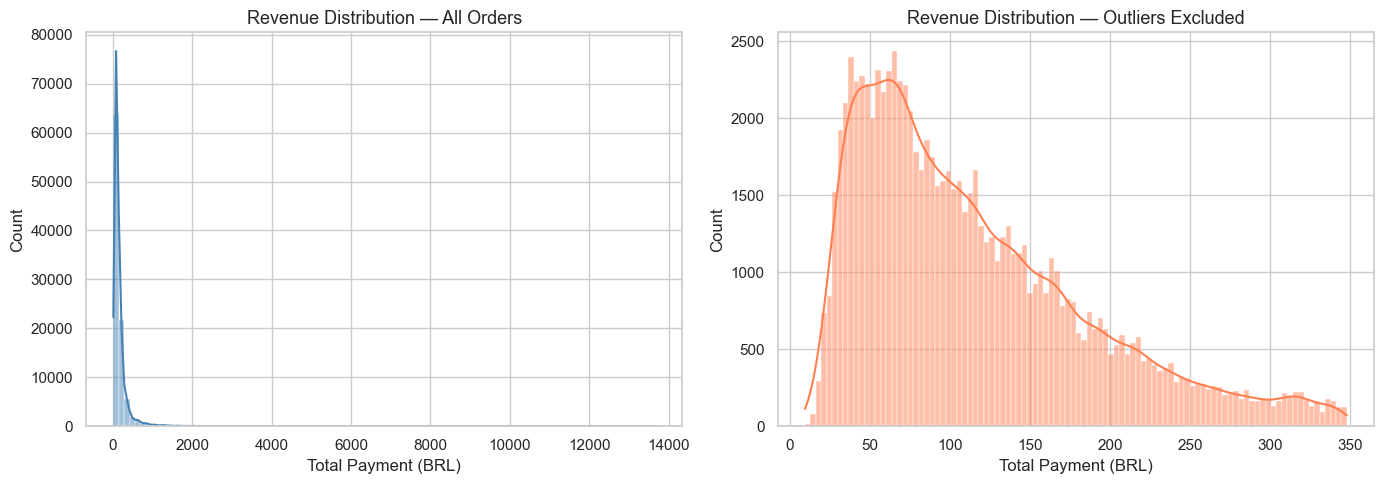

In [14]:
# Use the IQR (Interquartile Range) method to define outlier boundaries
# IQR = Q3 - Q1 (the range covering the middle 50% of values)
# Anything below Q1 - 1.5*IQR or above Q3 + 1.5*IQR is flagged as an outlier
Q1 = master['total_payment'].quantile(0.25)
Q3 = master['total_payment'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Create a boolean flag column instead of removing outliers
# True = outlier, False = normal order
master['is_revenue_outlier'] = (
    (master['total_payment'] < lower_bound) |
    (master['total_payment'] > upper_bound)
)

outlier_count = master['is_revenue_outlier'].sum()
outlier_pct   = outlier_count / len(master) * 100

print(f'Revenue outlier bounds: R${lower_bound:.2f} — R${upper_bound:.2f}')
print(f'Outliers flagged: {outlier_count:,} ({outlier_pct:.1f}% of orders)')

# Visualize the effect of outlier removal
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Full distribution including outliers
sns.histplot(master['total_payment'], bins=100, ax=axes[0], color='steelblue', kde=True)
axes[0].set_title('Revenue Distribution — All Orders', fontsize=13)
axes[0].set_xlabel('Total Payment (BRL)')

# Distribution excluding outliers — shows the 'normal' order range clearly
sns.histplot(
    master[~master['is_revenue_outlier']]['total_payment'],
    bins=100, ax=axes[1], color='coral', kde=True
)
axes[1].set_title('Revenue Distribution — Outliers Excluded', fontsize=13)
axes[1].set_xlabel('Total Payment (BRL)')

plt.tight_layout()
plt.savefig(os.path.join(DOCS_PATH, 'revenue_outlier_comparison.png'), dpi=150)
plt.show()

### 9c. Remove the order_status Column
Since we filtered to only 'delivered' orders, this column is now constant
and provides no analytical value — we drop it to keep the table clean.

In [15]:
# Drop columns that are no longer needed
# order_status is all 'delivered' — constant columns add noise, not signal
cols_to_drop = ['order_status']
master = master.drop(columns=cols_to_drop)

print(f'Final master table shape: {master.shape}')
print(f'\nColumns in master table:')
for col in master.columns:
    print(f'  {col}: {master[col].dtype}')

Final master table shape: (96442, 21)

Columns in master table:
  order_id: object
  customer_id: object
  order_purchase_timestamp: datetime64[ns]
  order_approved_at: datetime64[ns]
  order_delivered_carrier_date: datetime64[ns]
  order_delivered_customer_date: datetime64[ns]
  order_estimated_delivery_date: datetime64[ns]
  delivery_days: int64
  delivery_delay_days: int64
  customer_unique_id: object
  customer_city: object
  customer_state: object
  total_payment: float64
  payment_installments: float64
  payment_type: object
  item_count: int64
  total_items_price: float64
  total_freight: float64
  primary_category: object
  review_score: float64
  is_revenue_outlier: bool


---
## 10. Final Quality Check
A last sanity check before saving. We verify the master table is clean
and matches our expectations from the EDA phase.

In [16]:
print('=' * 55)
print('FINAL DATA QUALITY REPORT')
print('=' * 55)

# Shape
print(f'Total rows:             {len(master):,}')
print(f'Total columns:          {master.shape[1]}')

# Duplicates — there should be none since order_id is unique
dupes = master.duplicated(subset='order_id').sum()
print(f'Duplicate order_ids:    {dupes}')

# Missing values
total_missing = master.isnull().sum().sum()
print(f'Remaining missing vals: {total_missing}')

# Revenue range
print(f'Revenue range:          R${master["total_payment"].min():.2f} — R${master["total_payment"].max():.2f}')

# Date range
print(f'Date range:             {master["order_purchase_timestamp"].min().date()} to {master["order_purchase_timestamp"].max().date()}')

# Unique customers
print(f'Unique customers:       {master["customer_unique_id"].nunique():,}')

# Outlier flag
print(f'Revenue outliers:       {master["is_revenue_outlier"].sum():,} ({master["is_revenue_outlier"].mean()*100:.1f}%)')

print('=' * 55)

FINAL DATA QUALITY REPORT
Total rows:             96,442
Total columns:          21
Duplicate order_ids:    0
Remaining missing vals: 1
Revenue range:          R$9.59 — R$13664.08
Date range:             2016-10-03 to 2018-08-29
Unique customers:       93,323
Revenue outliers:       7,571 (7.9%)


---
## 11. Save the Cleaned Data
We save the master table to `data/processed/` as a CSV file.
This is the file all future phases (RFM, clustering, forecasting) will load from.
We never touch `data/raw/` again after this point.

In [17]:
# Save the master analytical table
# index=False prevents pandas from writing the row numbers as a column
output_path = os.path.join(PROCESSED_PATH, 'master_orders_clean.csv')
master.to_csv(output_path, index=False)

print(f'✅ Master table saved to:')
print(f'   {output_path}')
print(f'\nFile size: {os.path.getsize(output_path) / 1024 / 1024:.1f} MB')
print(f'Rows: {len(master):,} | Columns: {master.shape[1]}')
print('\n✅ Data Cleaning complete. Proceed to Phase 3 — RFM Analysis.')

✅ Master table saved to:
   /Users/omartouzani/Desktop/ecommerce-customer-analytics/data/processed/master_orders_clean.csv

File size: 24.8 MB
Rows: 96,442 | Columns: 21

✅ Data Cleaning complete. Proceed to Phase 3 — RFM Analysis.
